In [64]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors as mcolors
import corner
from scipy.interpolate import interp1d
from scipy import integrate
from scipy.stats import gaussian_kde
from pesummary.io import read
from pesummary.core.reweight import rejection_sampling
from simple_pe.param_est import SimplePESamples
from simple_pe import io
from simple_pe.param_est import find_metric_and_eigendirections, component_mass_prior_weight, uniform_e_prior_weight, loguniform_e_prior_weight

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
samples_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/tests/ecc_ci_test/outdir/output/'

# Read in files
peak_path = os.path.join(samples_dir, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
peak_snr_path = os.path.join(samples_dir, 'peak_snrs.json')
with open(peak_snr_path, 'r') as f:
    all_peak_snrs = json.load(f)
metric_path = os.path.join(samples_dir, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)
p_path = os.path.join(samples_dir, 'posterior_samples.dat')
p_samples = SimplePESamples(read(p_path).samples_dict)
p_samples.generate_all_posterior_samples()

# Uniform ecc prior

In [89]:
# Create grid points
npts = 501
c = np.linspace(23, 26, npts)
e = np.linspace(0, 0.37, npts)
chirps, eccs = np.meshgrid(c, e)
x_echirp = SimplePESamples({'chirp_mass': chirps.flatten(),
                            'ecc10': eccs.flatten()})

In [90]:
# Generate ecc weights
p_path = os.path.join(samples_dir, 'posterior_samples.dat')
p_samples = SimplePESamples(read(p_path).samples_dict)
p_samples.generate_all_posterior_samples()
ecc_weight_interp = interp1d(p_samples['ecc10'], p_samples['p_ecc']/np.max(p_samples['p_ecc']),
                             bounds_error=False, fill_value=0)
x_echirp['ecc_probs'] = ecc_weight_interp(x_echirp['ecc10'])

In [91]:
# Generate samples and reweight with prior
metric_samples = metric.generate_samples(10**6)
dx_directions = ['ecc10sqrd', 'chirp_mass', 'symmetric_mass_ratio', 'chi_align']
reweighted_metric_samples = component_mass_prior_weight(metric_samples, dx_directions)
reweighted_metric_samples = uniform_e_prior_weight(reweighted_metric_samples, dx_directions)

# Construct gaussian kde and apply to grid
reweighted_metric_kde = gaussian_kde([reweighted_metric_samples['chirp_mass'], np.sqrt(reweighted_metric_samples['ecc10sqrd'])], bw_method=0.5)
x_echirp['prior_metric'] = reweighted_metric_kde([x_echirp['chirp_mass'], x_echirp['ecc10']])
x_echirp['prior_metric'] /= np.max(x_echirp['prior_metric'])

In [92]:
# Generate posterior pdf
posterior = rejection_sampling(reweighted_metric_samples, ecc_weight_interp(np.sqrt(reweighted_metric_samples['ecc10sqrd'])))
posterior_kde = gaussian_kde([posterior['chirp_mass'], np.sqrt(posterior['ecc10sqrd'])], bw_method=0.5)
x_echirp['posterior'] = posterior_kde([x_echirp['chirp_mass'], x_echirp['ecc10']])
x_echirp['posterior'] /= np.max(x_echirp['posterior'])

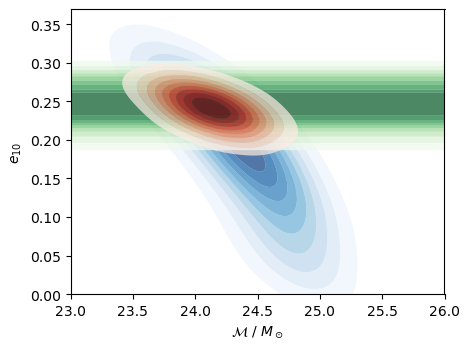

In [108]:
# Make plot
plt.figure(figsize=(0.75*6.4, 0.75*4.8))
alpha = 0.7
colours = ['Blues', 'Greens', 'Reds']
for i, key in enumerate(['prior_metric', 'ecc_probs', 'posterior']):
    plt.contourf(x_echirp['chirp_mass'].reshape(npts,npts), 
                 x_echirp['ecc10'].reshape(npts,npts), 
                 x_echirp[key].reshape(npts,npts), alpha=alpha,
                 levels=np.linspace(0.1,1,10), antialiased=True,
                 cmap=colours[i])
    
plt.xlabel('$\mathcal{M}~/~M_\odot$')
plt.ylabel('$e_{10}$')
plt.xlim(23, 26)
plt.ylim(0, 0.37)
plt.tight_layout()
plt.savefig('Figures/ecc_weight_plot.png', dpi=450)
plt.show()